In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import deque

Watts and Strogatz's small-world network model

In [2]:
def watts_strogatz_model(n, k, p):
    if k >= n or k % 2 != 0:
        raise ValueError("k must be smaller than n and even.")

    adjacency_list = {i: set() for i in range(n)}
    half_k = k // 2
    for i in range(n):
        for j in range(1, half_k + 1):
            neighbor = (i + j) % n
            adjacency_list[i].add(neighbor)
            adjacency_list[neighbor].add(i)

    # Rewire edges with probability p
    for i in range(n):
        for neighbor in list(adjacency_list[i]):
            if random.random() < p:
                adjacency_list[i].remove(neighbor)
                adjacency_list[neighbor].remove(i)

                new_neighbor = random.choice([x for x in range(n) if x != i and x not in adjacency_list[i]])
                adjacency_list[i].add(new_neighbor)
                adjacency_list[new_neighbor].add(i)

    return adjacency_list

In [3]:
def compute_clustering_coefficient(graph):
    clustering = []
    for node in graph:
        neighbors = list(graph[node])
        k = len(neighbors)
        if k < 2:
            clustering.append(0)
            continue

        links = sum(1 for u, v in combinations(neighbors, 2) if v in graph[u])
        clustering.append(2 * links / (k * (k - 1)))

    return np.mean(clustering)

def compute_characteristic_path_length(graph, n):
    def bfs(start):
        distances = {start: 0}
        queue = deque([start])
        while queue:
            node = queue.popleft()
            for neighbor in graph[node]:
                if neighbor not in distances:
                    distances[neighbor] = distances[node] + 1
                    queue.append(neighbor)
        return distances

    total_length = 0
    path_counts = 0

    for node in range(n):
        distances = bfs(node)
        path_counts += len(distances) - 1
        total_length += sum(distances.values())

    return total_length / path_counts

In [ ]:
n = 5000   # Number of nodes
k = 6      # Each node is connected to k nearest neighbors initially
p_values = np.logspace(-4, 0, 20)

In [ ]:
C0, L0 = None, None
C_values, L_values = [], []

for p in p_values:
    graph = watts_strogatz_model(n, k, p)

    C = compute_clustering_coefficient(graph)
    L = compute_characteristic_path_length(graph, n)

    if C0 is None:
        C0, L0 = C, L

    C_values.append(C / C0)
    L_values.append(L / L0)

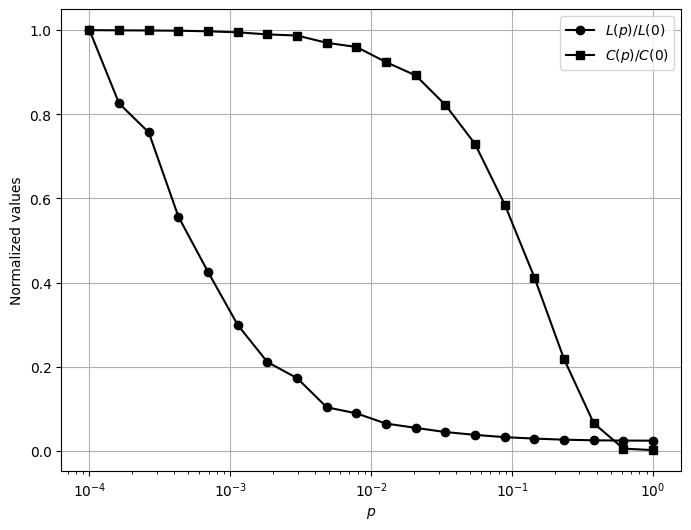

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(p_values, L_values, 'ko-', label='$L(p) / L(0)$')  # Characteristic path length
plt.plot(p_values, C_values, 'ks-', label='$C(p) / C(0)$')  # Clustering coefficient
plt.xscale('log')
plt.xlabel('$p$')
plt.ylabel('Normalized values')
plt.legend()
plt.grid()
plt.show()